In [1]:
# Notebook includes the code from main.py

In [2]:
# import libraries

#import libraries to conduct eda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# import scipy for statistical analysis in eda
#!pip install scipy
from scipy import stats

# import re to help with wildmatch for column name standardization
#import re

# import datetime to set timestamp on pdf report
from datetime import datetime

print("All required libraries installed")


All required libraries installed


In [3]:
# data file names 

data_file_hurr = "../data/ibtracs.NA.list.v04r01.csv"

data_file_gas = "../data/aaa_fl_metros_wayback_2022_2025.csv"
#"../data/gas_coordinates.csv"

data_file_coast = "../data/Gulf_Coast_Coords.csv"

In [4]:
# import file loading functions
from file_load import df_import

In [5]:
# import data files

hurr_data = df_import(data_file_hurr)
hurr_data.name = 'hurr_data'

gas_data = df_import(data_file_gas)
gas_data.name = 'gas_data'

coast_pt_data = df_import(data_file_coast)

C:\Users\eenoo\Downloads\CSCI_5502\Project\src\file_load.py:6: DtypeWarning: Columns (1,2,3,8,9,14,19,20,23,24,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  pri_data = pd.read_csv(datafile)


Successfully loaded ../data/ibtracs.NA.list.v04r01.csv
Successfully loaded ../data/aaa_fl_metros_wayback_2022_2025.csv
Successfully loaded ../data/Gulf_Coast_Coords.csv


In [6]:
# import stats functions
from stats_look import *

In [7]:
print(f'{hurr_data.name}')

hurr_data


In [8]:
# run stats on baseline data

# basic analysis on hurricane data
sum_stats(hurr_data)

# basic analysis on gas data
sum_stats(gas_data)


Statistics for hurr_data
<bound method DataFrame.info of                   SID SEASON NUMBER BASIN SUBBASIN     NAME  \
0                       Year                                  
1       1851175N26270   1851      5   NaN       GM  UNNAMED   
2       1851175N26270   1851      5   NaN       GM  UNNAMED   
3       1851175N26270   1851      5   NaN       GM  UNNAMED   
4       1851175N26270   1851      5   NaN       GM  UNNAMED   
...               ...    ...    ...   ...      ...      ...   
127645  2025291N11319   2025     93   NaN      NaN  MELISSA   
127646  2025291N11319   2025     93   NaN      NaN  MELISSA   
127647  2025291N11319   2025     93   NaN      NaN  MELISSA   
127648  2025291N11319   2025     93   NaN      NaN  MELISSA   
127649  2025291N11319   2025     93   NaN      NaN  MELISSA   

                   ISO_TIME NATURE            LAT           LON  ...  \
0                                   degrees_north  degrees_east  ...   
1       1851-06-23 12:00:00     TS        

In [9]:
# import data cleaning functions
from clean import *

In [10]:
# Clean hurricane data and generate data frames for cleaned hurricane data, list of hurricanes, and summary list of hurricanes with maximum storm category observed
# Generates data frames with ALL data and a set of filtered data frames for "recent" (2022-2025)
hurr_data_redux, hurr_list, hurr_sum_list, hurr_data_redux_rec, hurr_list_rec, hurr_sum_list_rec= hurr_clean(hurr_data)

# Name output data frames
hurr_data_redux.name = 'hurr_data_redux'
hurr_list.name = 'hurr_list'
hurr_sum_list.name = 'hurr_sum_list'
hurr_data_redux_rec.name = 'hurr_data_redux_rec'
hurr_list_rec.name = 'hurr_list_rec'
hurr_sum_list_rec.name = 'hurr_sum_list_rec'

Cleaning hurr_data
          Unit
SID           
SEASON    Year
NUMBER        
BASIN         
SUBBASIN      
(174, 1)
Data table columns reduced to 47
Hurricane data cleaning complete


In [11]:
# List metro areas of interest
# all FL cities selected to represent the perimeter

metro_all = ['Pensacola', 'Tallahassee', 'Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral', 'Miami','West Palm Beach-Boca Raton','Melbourne-Titusville','Daytona Beach','Jacksonville']

# East coast of FL
metro_east = ['Miami','West Palm Beach-Boca Raton','Melbourne-Titusville','Daytona Beach','Jacksonville']

# West coast of FL (exl panhandle)
metro_west = ['Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral']

# Panhandle of FL
metro_ph = ['Pensacola', 'Tallahassee']

# Gulf Coast of FL (West + Panhandle)
metro_gulf = ['Pensacola', 'Tallahassee', 'Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral']


In [12]:
# Clean gas station data and generate data frame for cleaned gas station data
gas_data_redux = gas_clean(gas_data)
gas_data_redux.name = 'gas_data_redux'

Cleaning gas_data
Gas data cleaning complete


In [13]:
# run stats on cleaned data
# basic analysis on cleaned hurricane data
sum_stats(hurr_data_redux)

Statistics for hurr_data_redux
<bound method DataFrame.info of                   SID  SEASON  NUMBER BASIN SUBBASIN     NAME  \
1       1851175N26270    1851       5  NATL       GM  UNNAMED   
2       1851175N26270    1851       5  NATL       GM  UNNAMED   
3       1851175N26270    1851       5  NATL       GM  UNNAMED   
4       1851175N26270    1851       5  NATL       GM  UNNAMED   
5       1851175N26270    1851       5  NATL       GM  UNNAMED   
...               ...     ...     ...   ...      ...      ...   
127645  2025291N11319    2025      93  NATL      NaN  MELISSA   
127646  2025291N11319    2025      93  NATL      NaN  MELISSA   
127647  2025291N11319    2025      93  NATL      NaN  MELISSA   
127648  2025291N11319    2025      93  NATL      NaN  MELISSA   
127649  2025291N11319    2025      93  NATL      NaN  MELISSA   

                  ISO_TIME NATURE   LAT   LON  ... USA_EYE  USA_GUST  \
1      1851-06-23 12:00:00     TS  26.1 -90.4  ...     NaN             
2      1851-

In [14]:
# basic analysis on cleaned gas data
sum_stats(gas_data_redux)


Statistics for gas_data_redux
<bound method DataFrame.info of                             metro       date   regular    mid   premium  \
0       Bradenton-Sarasota-Venice 2022-01-21  3.236000  3.625  3.915000   
1       Bradenton-Sarasota-Venice 2022-01-22  3.254667  3.639  3.929667   
2       Bradenton-Sarasota-Venice 2022-01-23  3.273333  3.653  3.944333   
3       Bradenton-Sarasota-Venice 2022-01-24  3.292000  3.667  3.959000   
4       Bradenton-Sarasota-Venice 2022-01-25  3.310667  3.681  3.973667   
...                           ...        ...       ...    ...       ...   
34555  West Palm Beach-Boca Raton 2025-12-26  2.940500  3.410  3.724000   
34556  West Palm Beach-Boca Raton 2025-12-27  2.917000  3.350  3.682000   
34557  West Palm Beach-Boca Raton 2025-12-28  2.912000  3.333  3.692000   
34558  West Palm Beach-Boca Raton 2025-12-29  2.901000  3.304  3.679000   
34559  West Palm Beach-Boca Raton 2025-12-30  2.954000  3.405  3.757000   

         diesel  year  month   date_k

In [15]:
# Run visualizations

from eda_visuals import *

Starting EDA for hurr_sum_list


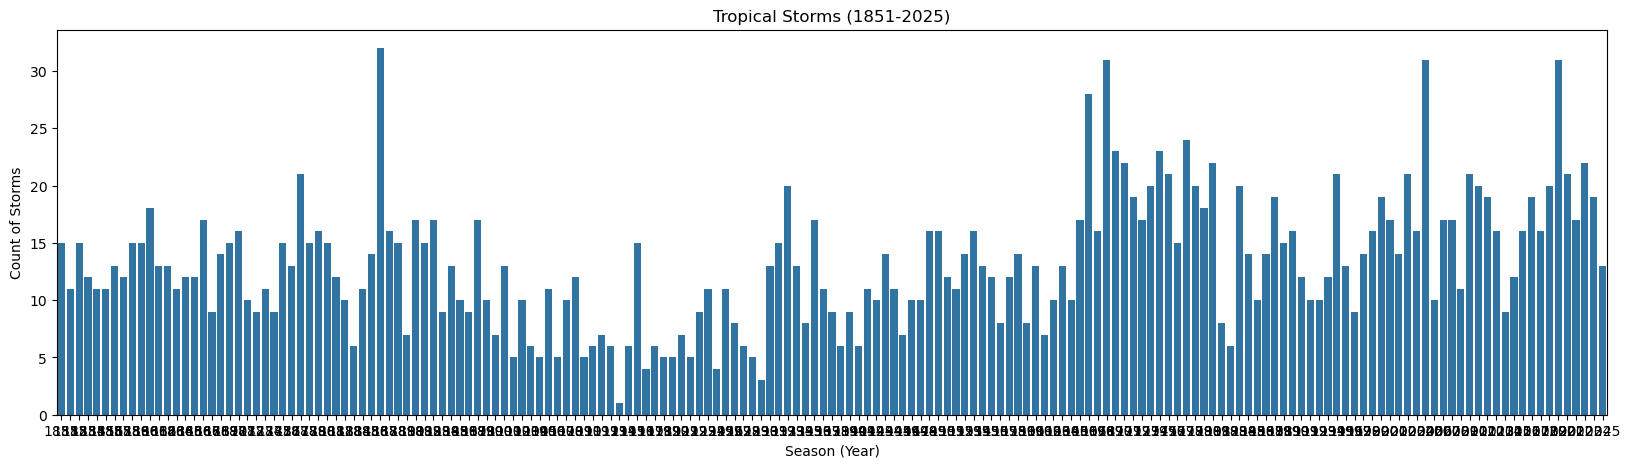

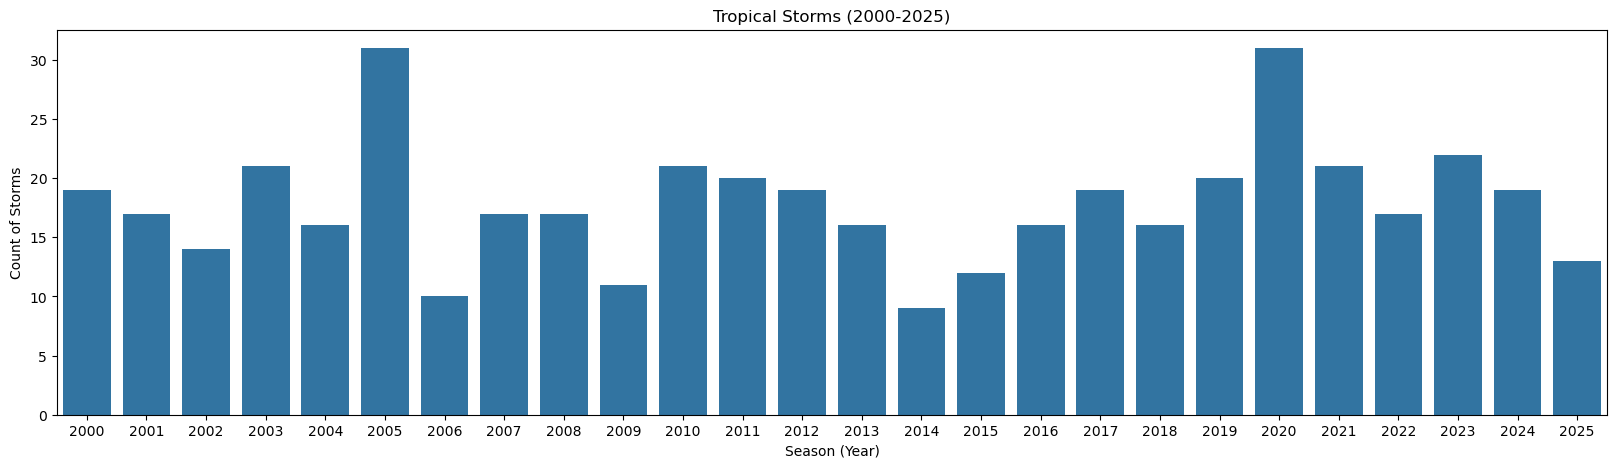

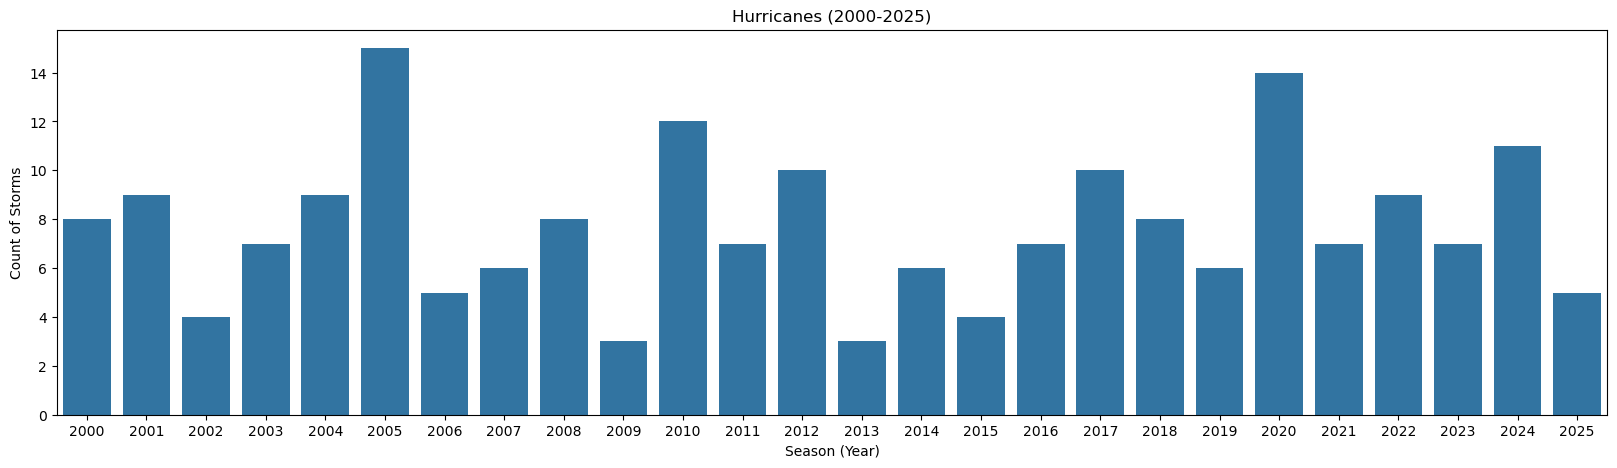

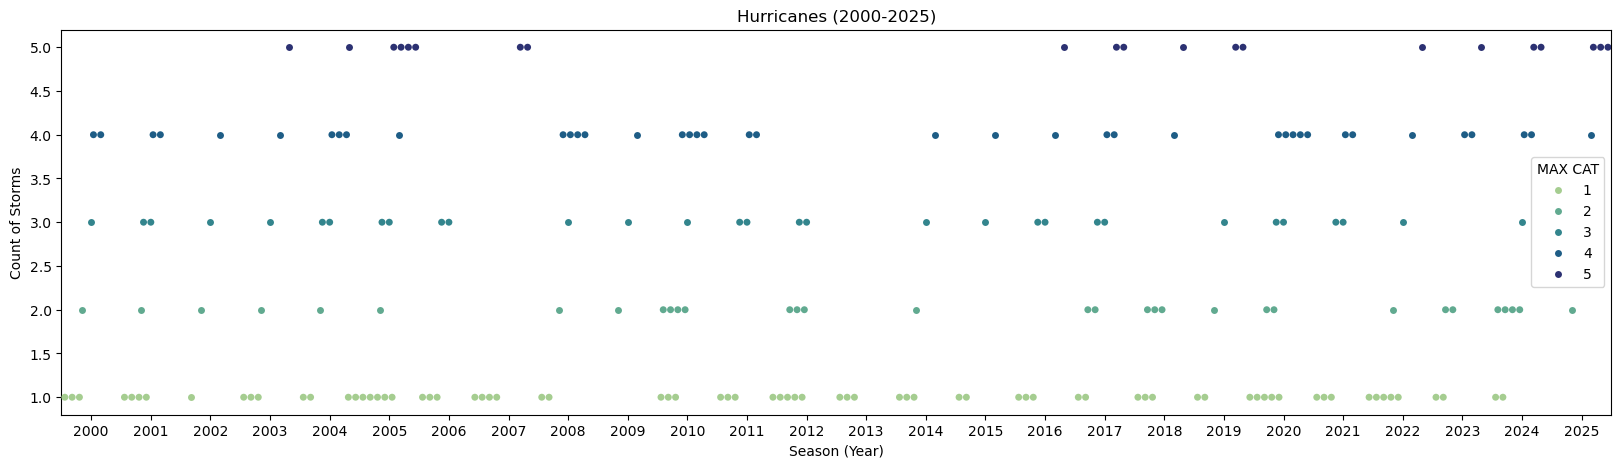

Starting EDA for hurr_sum_list_rec


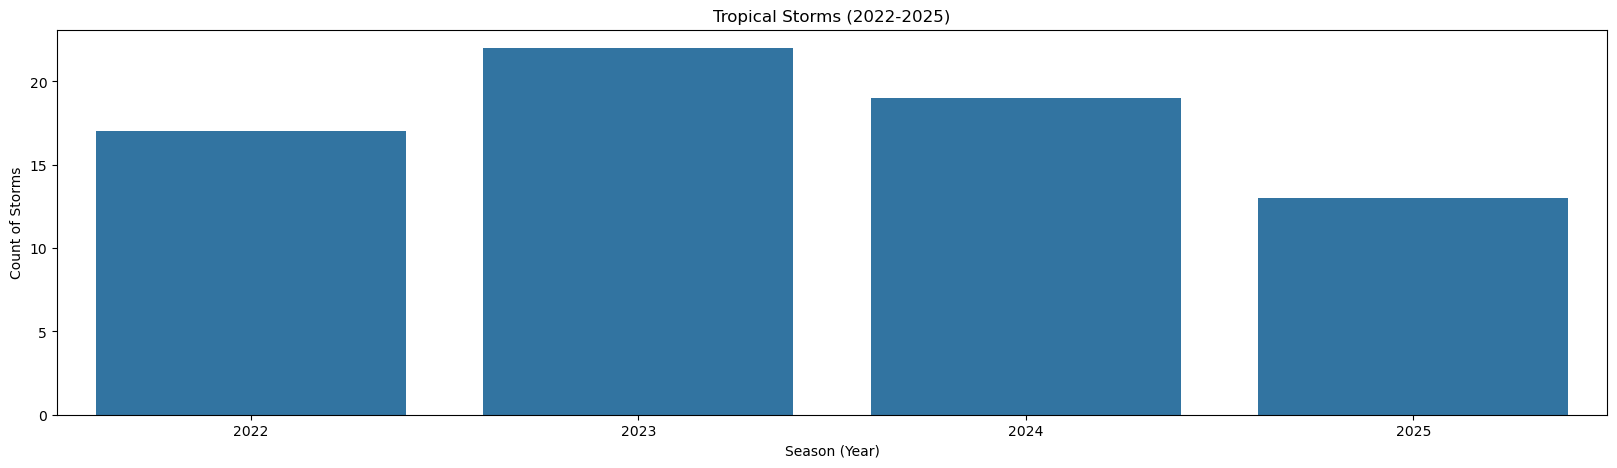

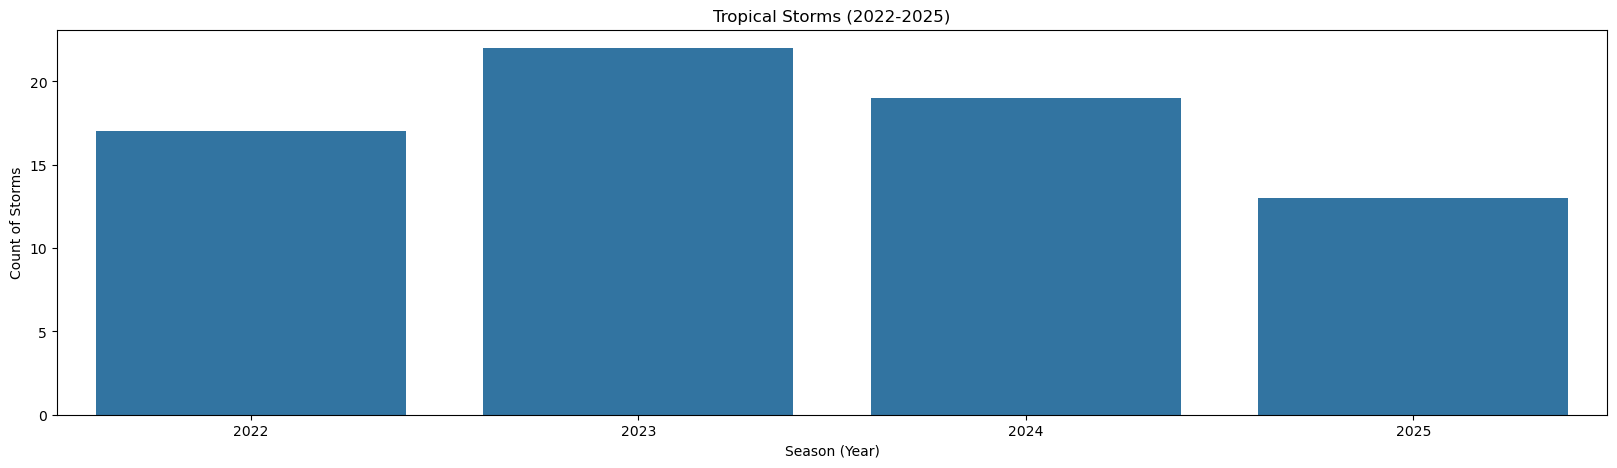

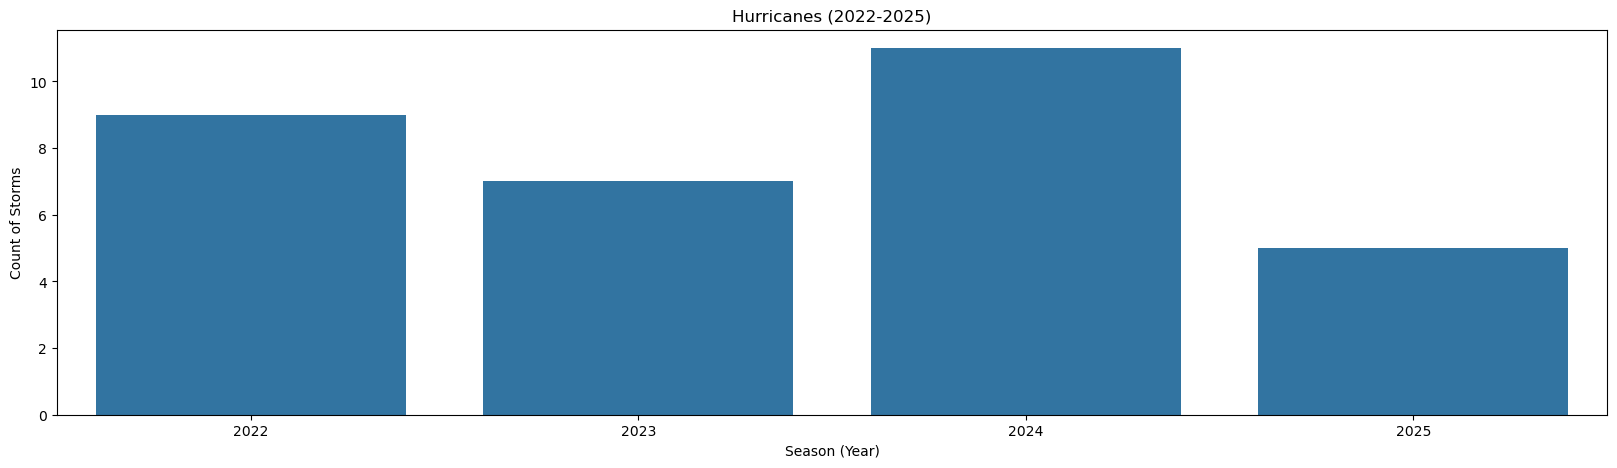

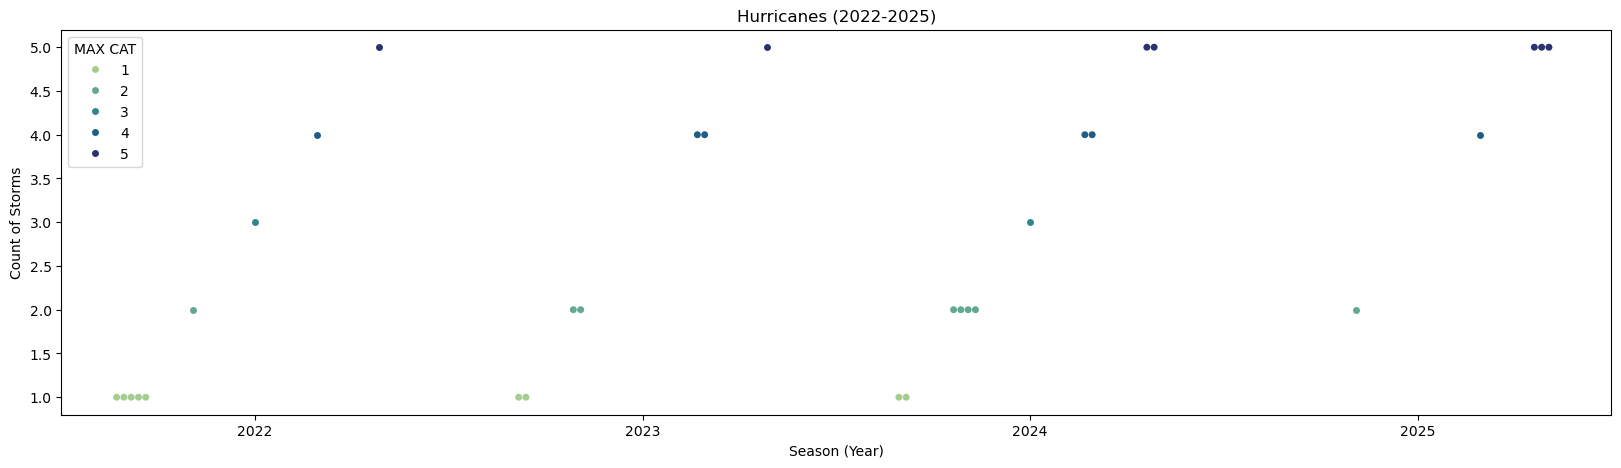

In [16]:
# Hurricane Overview Visuals
hurr_visuals(hurr_sum_list)

hurr_visuals(hurr_sum_list_rec)


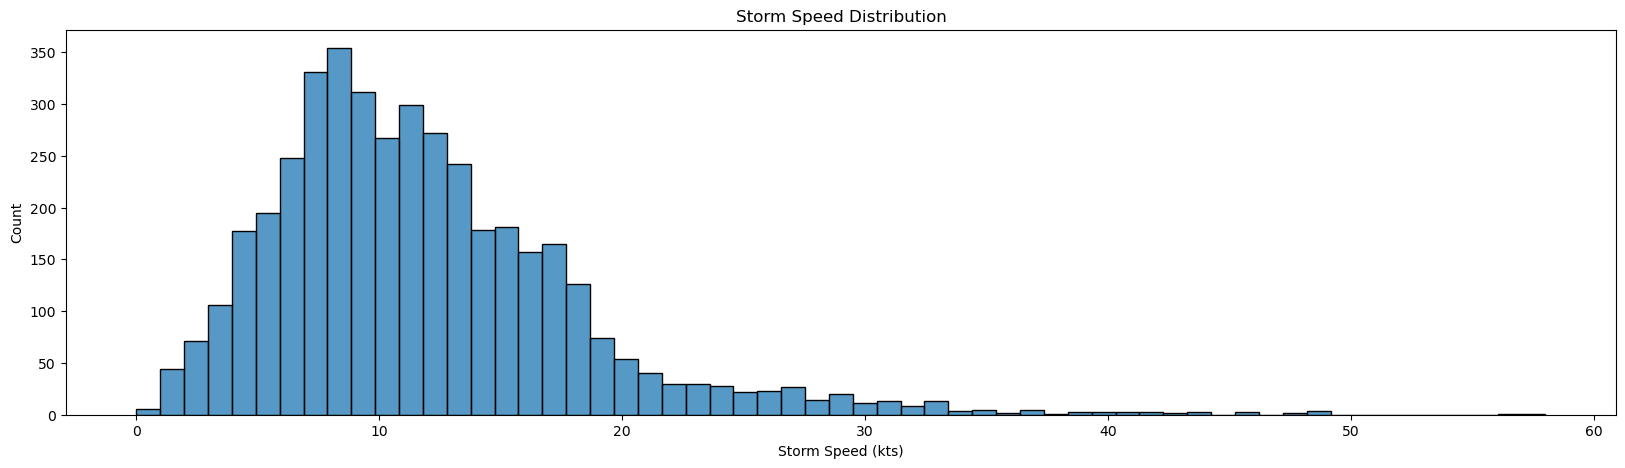

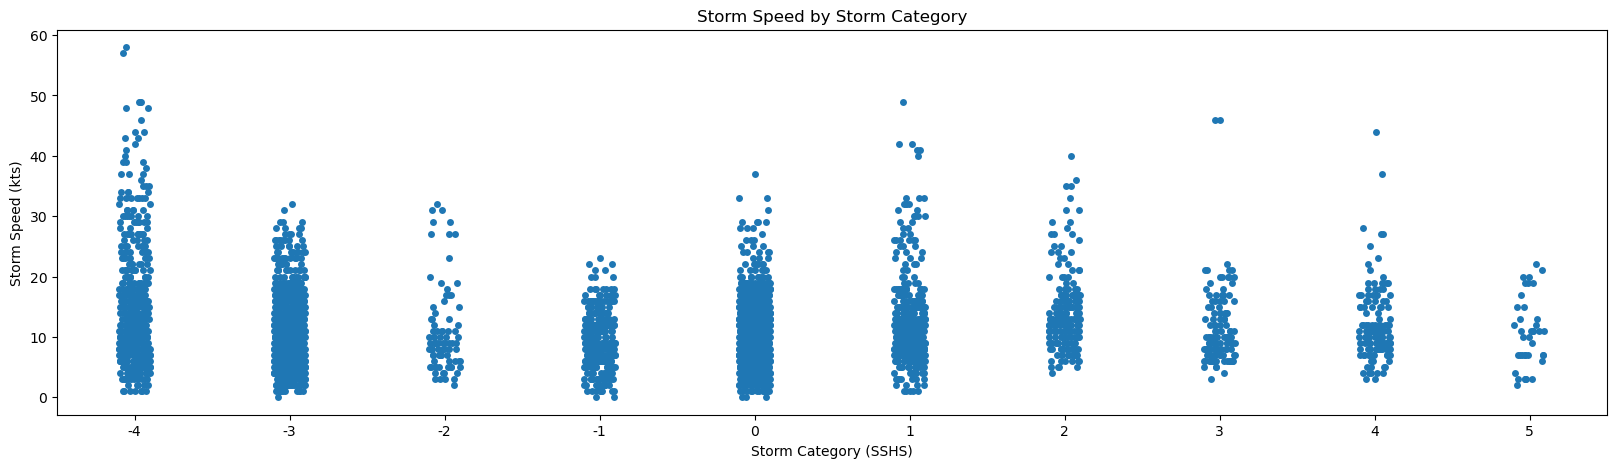

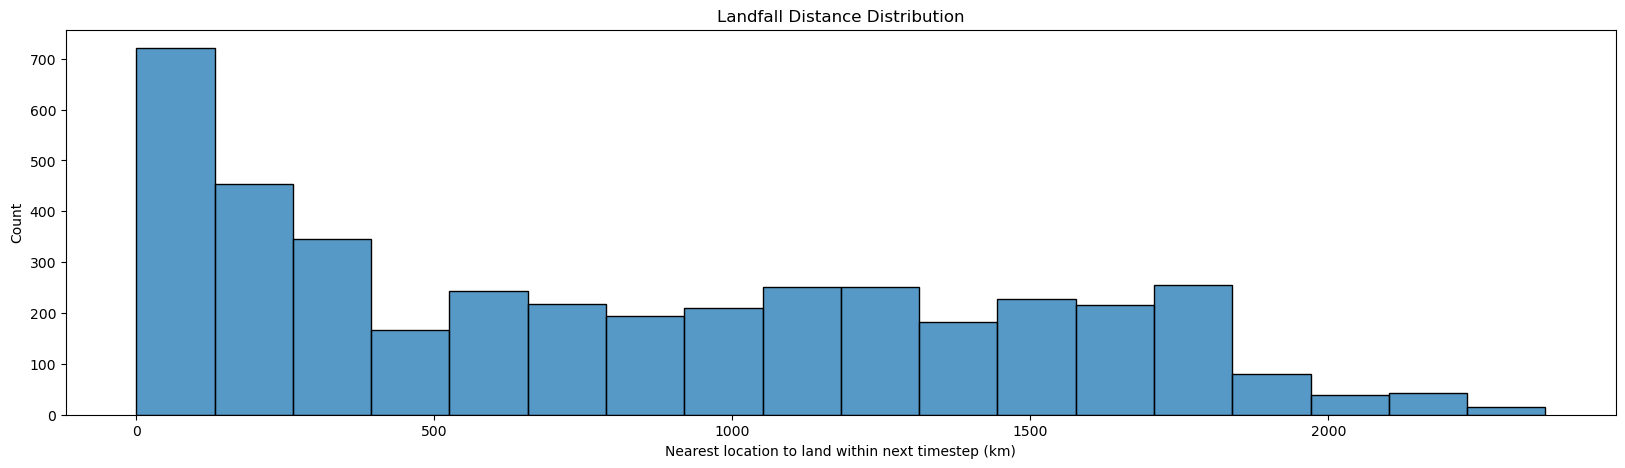

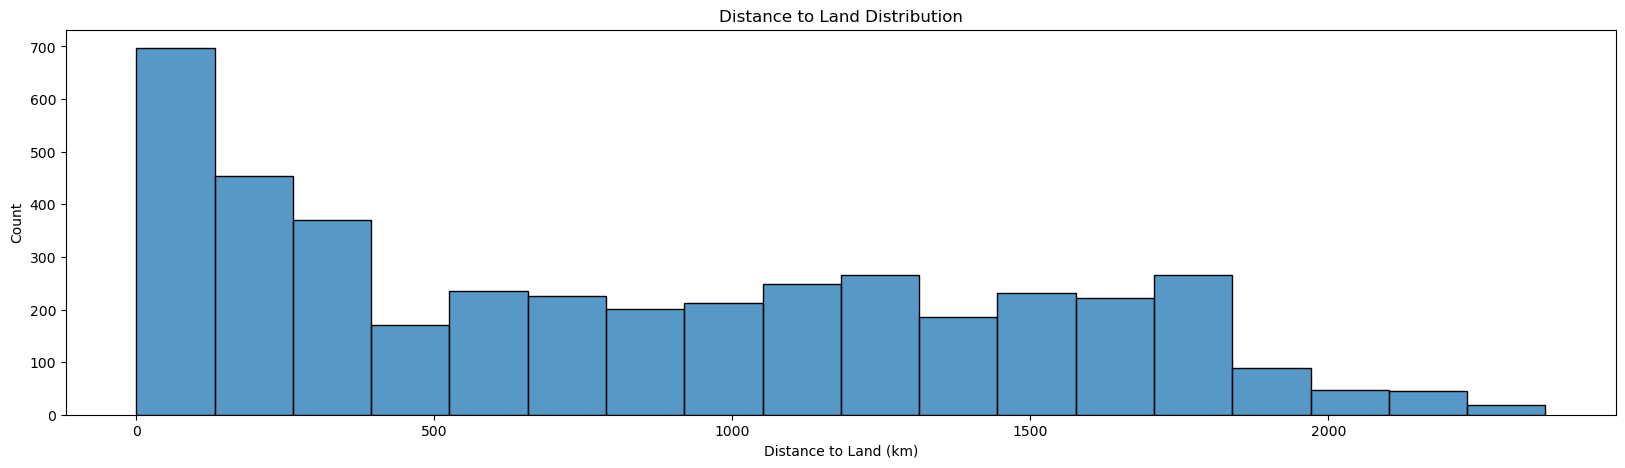

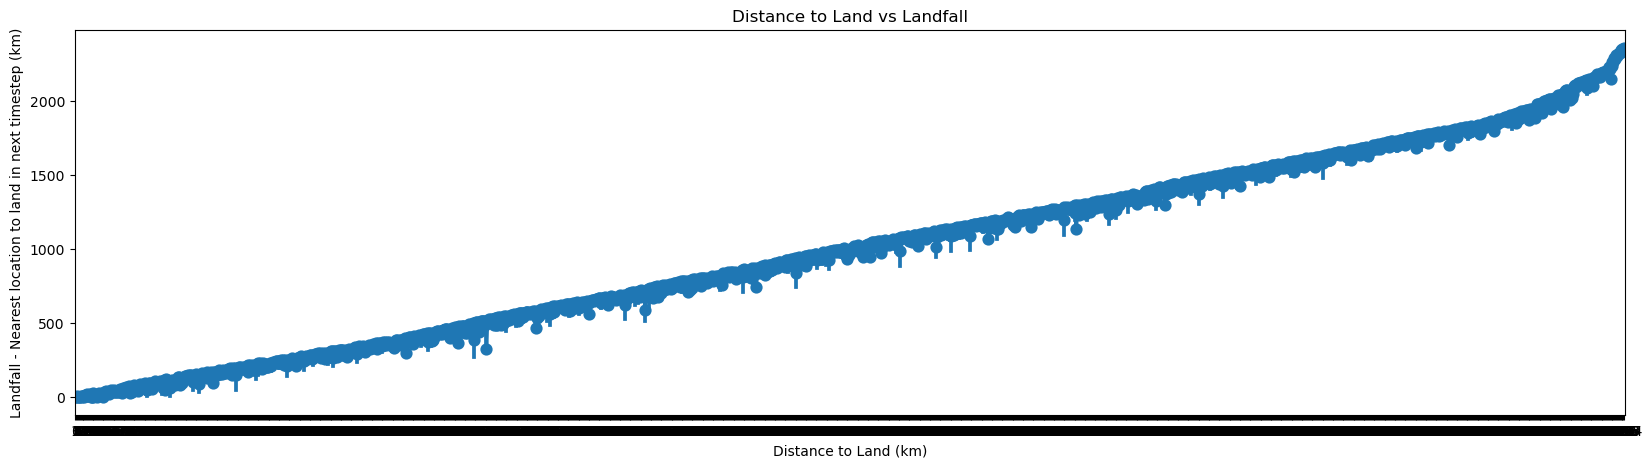

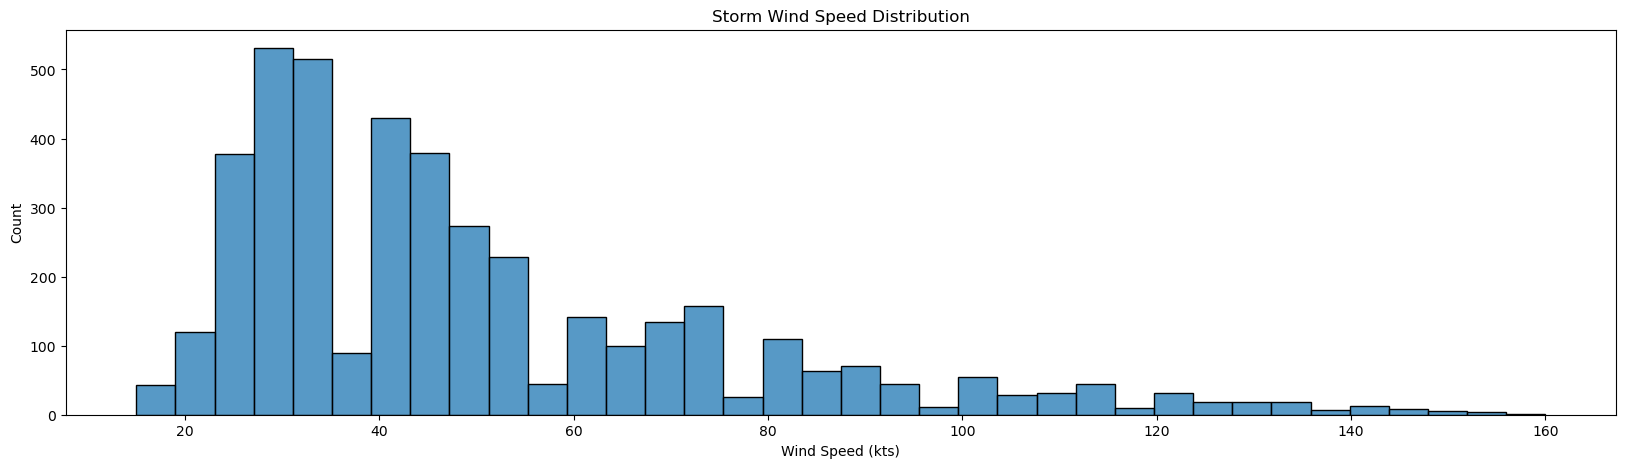

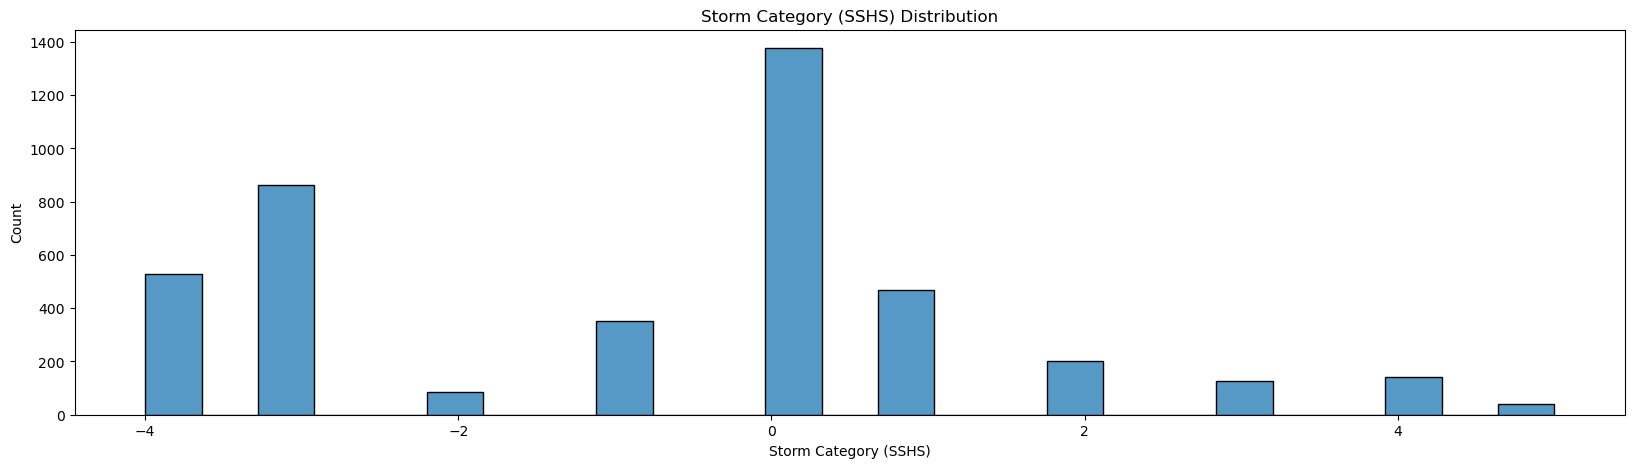

In [17]:
# Hurricane Stats Visuals
stats_hurr_viz(hurr_data_redux_rec)

Starting overview for gas_data_redux and ['Pensacola', 'Tallahassee', 'Tampa-St. Petersburg-Clearwater', 'Fort Myers-Cape Coral', 'Miami', 'West Palm Beach-Boca Raton', 'Melbourne-Titusville', 'Daytona Beach', 'Jacksonville']


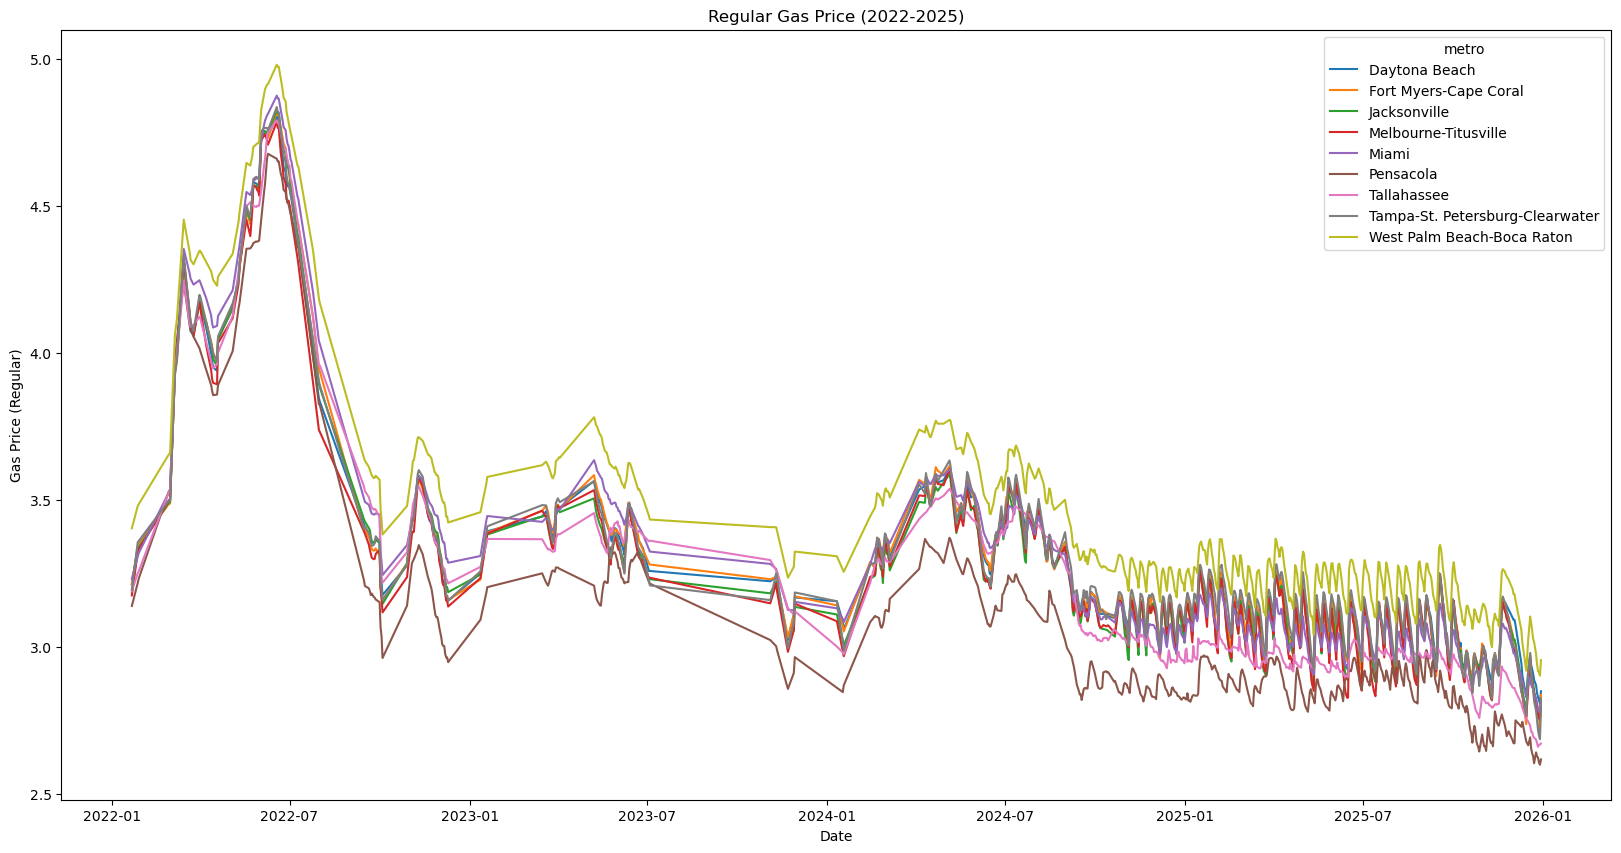

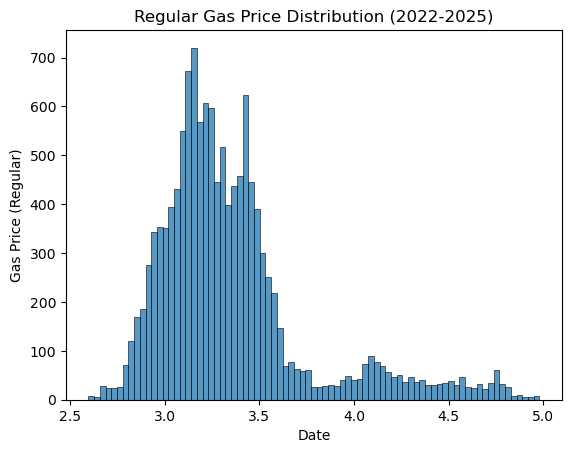

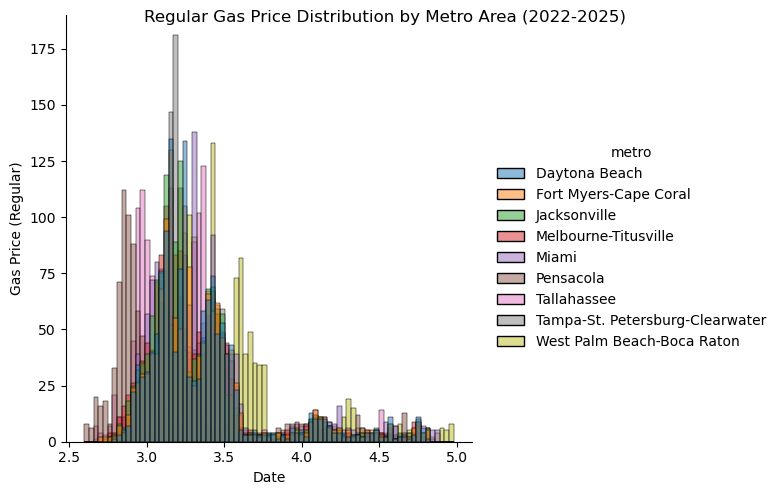

Starting EDA for gas_data_redux and ['Miami', 'West Palm Beach-Boca Raton', 'Melbourne-Titusville', 'Daytona Beach', 'Jacksonville']


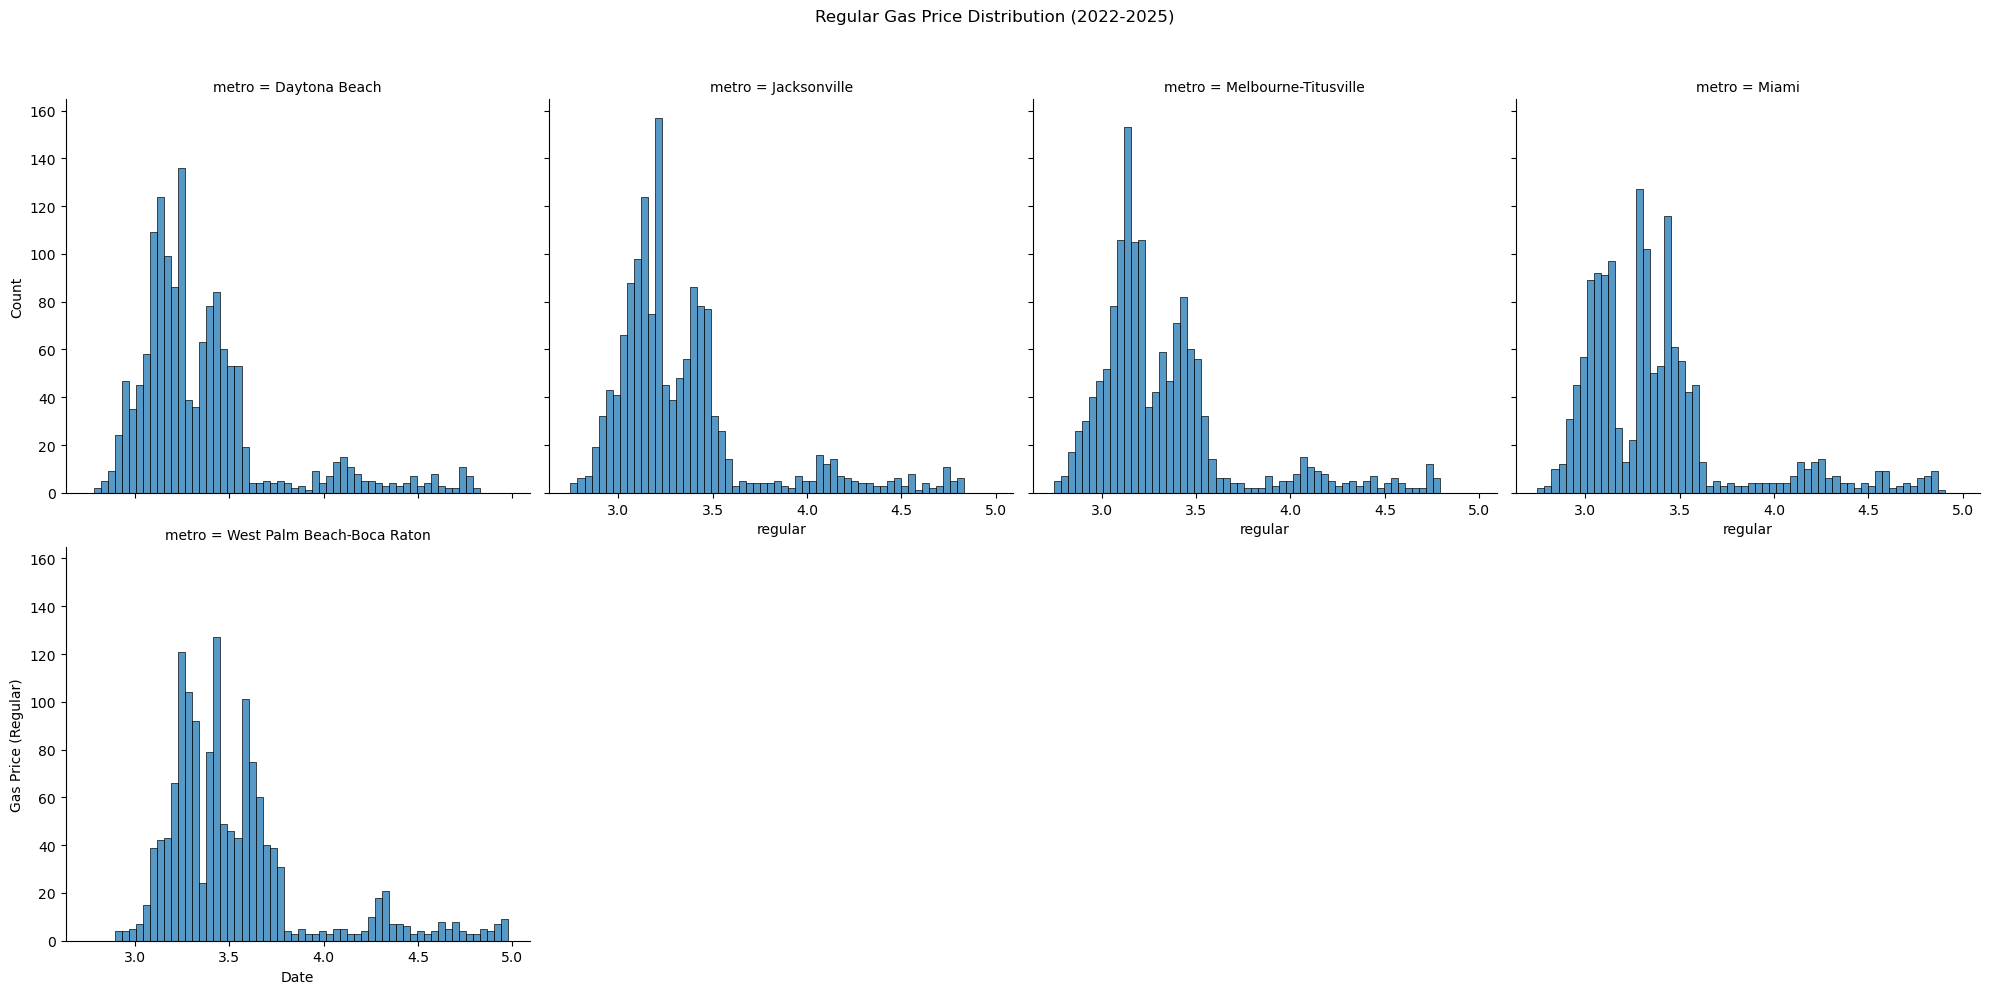

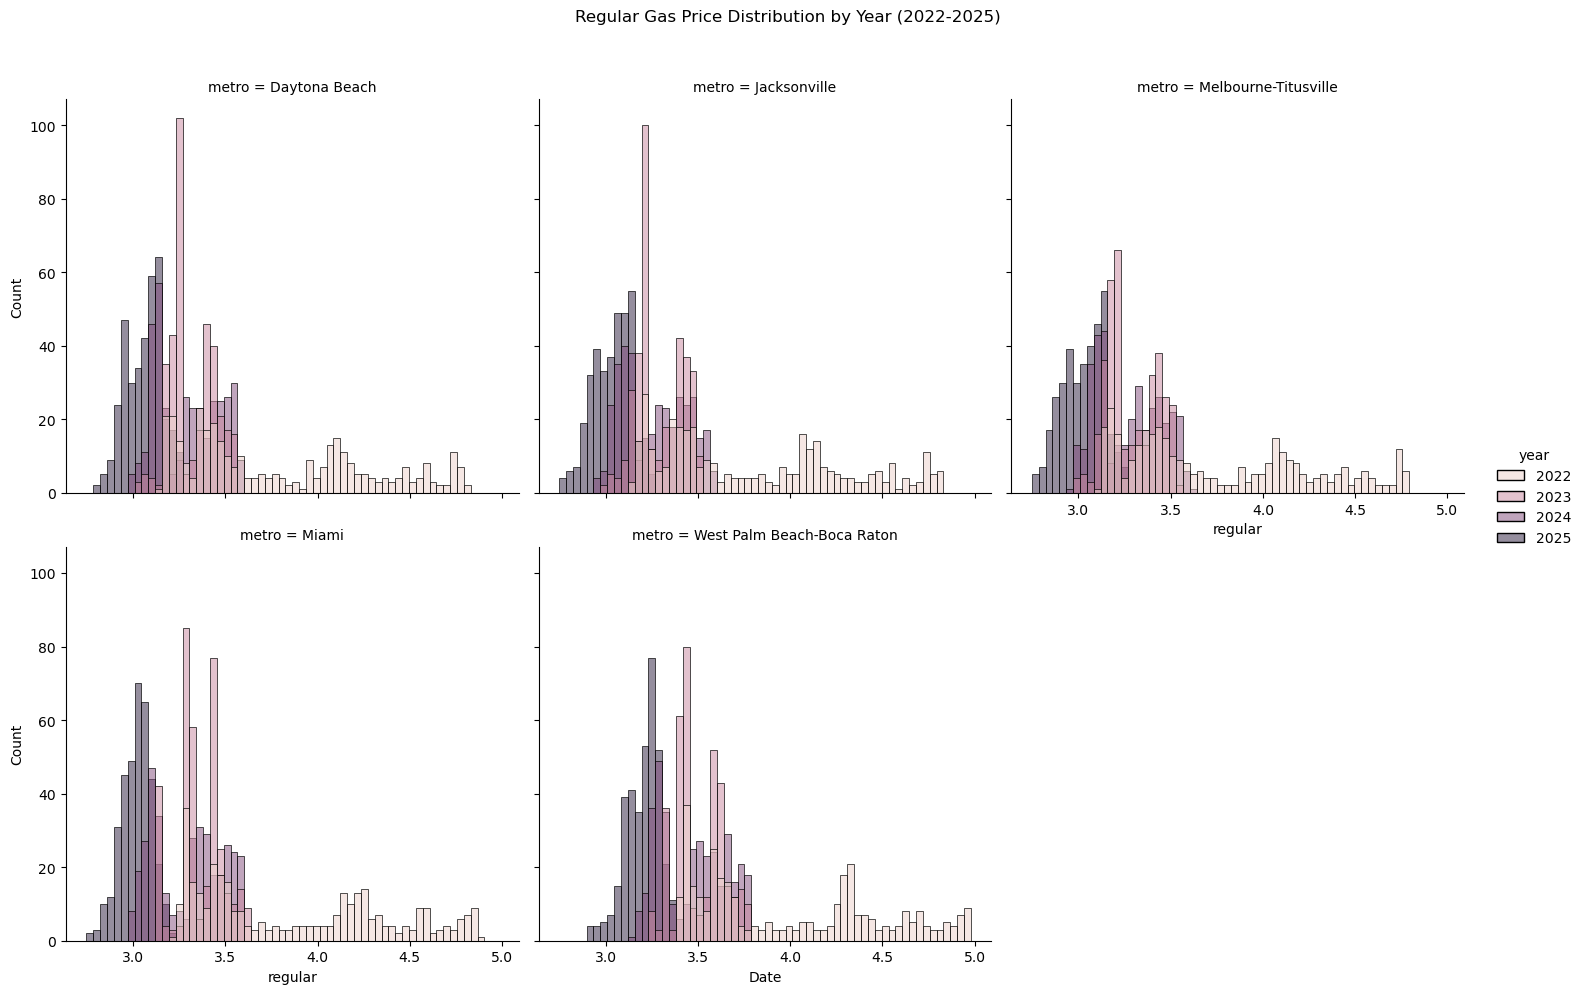

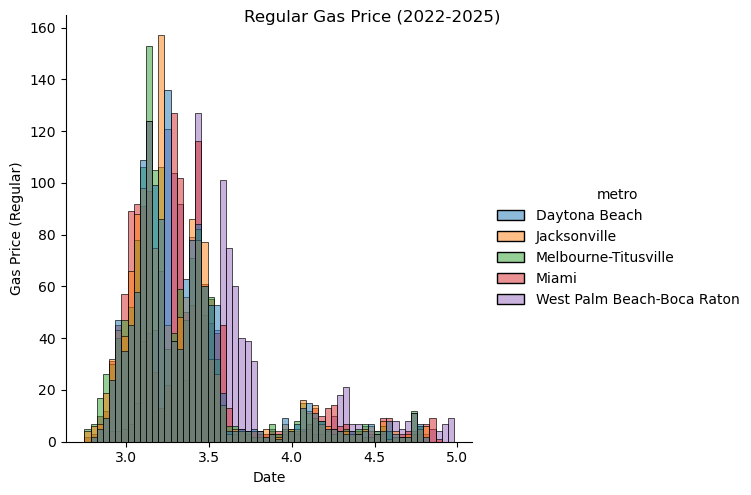

In [18]:
# Gas Overview Visuals
gas_visuals_ov(gas_data_redux, metro_all)

gas_visuals(gas_data_redux, metro_east)

#gas_visuals(gas_data_redux, metro_gulf)